# Algorithm 3.1 — Kepler's equation (ellipse) by Newton's method

**Goal:** given the eccentricity $e$ and the mean anomaly $M$ (which is just a clock — it advances uniformly with time), solve **Kepler's equation** $M = E - e\sin E$ for the eccentric anomaly $E$.

**Code (answer key):** [`kepler_E`](../curtis/algorithms/alg_3_1_kepler_E.py) · **Book:** §3.6, Algorithm 3.1 · **Worked example:** 3.2

This is the first algorithm where **time** enters: 4.1/4.2 described the orbit *at an instant*; Kepler's equation tells you *where the satellite is at a given time.*

## Read first

| Symbol | Name | Meaning |
|---|---|---|
| $M$ | mean anomaly | a uniform clock: $M = n\,(t - t_p)$, with $n=\sqrt{\mu/a^3}$ |
| $E$ | eccentric anomaly | the angle we solve for (auxiliary-circle angle) |
| $\theta$ | true anomaly | the real angle from perigee (from 4.1) |
| $e$ | eccentricity | $0\le e<1$ here (ellipse) |

**Kepler's equation** $\;M = E - e\sin E\;$ (Eq 3.14) links them. It cannot be rearranged for $E$ in closed form — it is *transcendental* — so we solve it numerically with Newton's method.

## The picture (three clocks for one position)

A satellite's position on its orbit can be named three ways, all measured from perigee:

- **$\theta$ (true anomaly)** — the actual geometric angle (what you computed in 4.1). Moves *fast* near perigee, *slow* near apogee.
- **$E$ (eccentric anomaly)** — the angle on the *auxiliary circle* (radius $a$) directly above the satellite. A convenient middle-man.
- **$M$ (mean anomaly)** — *not an angle at all*: it is proportional to the **area swept** since perigee, and by Kepler's 2nd law area $\propto$ time. So $M$ ticks at a constant rate; it is the clock.

Going forward in time is easy in $M$ (just $M=n(t-t_p)$) but the geometry lives in $\theta$. **Kepler's equation is the bridge $M \to E$, and then $E\to\theta$ is a closed-form formula.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

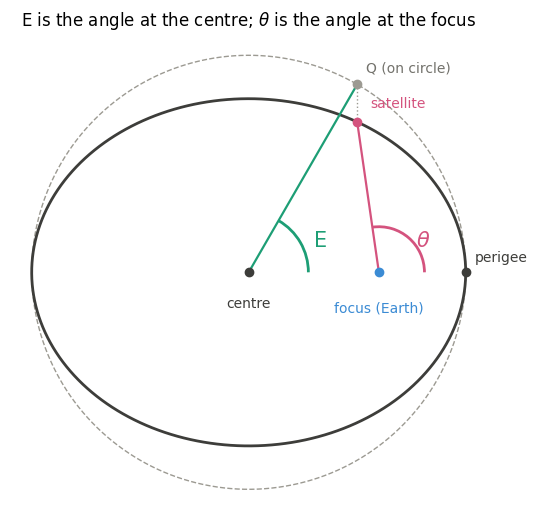

In [2]:
# The auxiliary-circle construction (illustrative: e=0.6, E=60 deg).
a, e_ill = 1.0, 0.6
b, c = a*np.sqrt(1 - e_ill**2), a*e_ill
E_ill = np.radians(60)
t = np.linspace(0, 2*np.pi, 400)

C = np.array([0.0, 0.0])                       # ellipse centre
F = np.array([c, 0.0])                         # focus (Earth)
Q = np.array([a*np.cos(E_ill), a*np.sin(E_ill)])   # on the auxiliary circle
P = np.array([a*np.cos(E_ill), b*np.sin(E_ill)])   # the satellite, on the ellipse

fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.plot(a*np.cos(t), a*np.sin(t), '--', color='#9c9a92', lw=1)    # auxiliary circle
ax.plot(a*np.cos(t), b*np.sin(t), color='#3d3d3a', lw=2)          # orbit (ellipse)
ax.plot([C[0], Q[0]], [C[1], Q[1]], color='#1D9E75', lw=1.6)      # radius -> E
ax.plot([F[0], P[0]], [F[1], P[1]], color='#D4537E', lw=1.6)      # focus -> theta
ax.plot([Q[0], P[0]], [Q[1], P[1]], color='#9c9a92', lw=1, ls=':')

ax.add_patch(Arc(C, 0.55, 0.55, theta1=0, theta2=60, color='#1D9E75', lw=2))
thP = np.degrees(np.arctan2(P[1]-F[1], P[0]-F[0]))
ax.add_patch(Arc(F, 0.42, 0.42, theta1=0, theta2=thP, color='#D4537E', lw=2))

for p, col in [(C, '#3d3d3a'), (F, '#3B8BD4'), (P, '#D4537E'),
               (Q, '#9c9a92'), (np.array([a, 0.0]), '#3d3d3a')]:
    ax.plot(*p, 'o', color=col, ms=6)
ax.annotate('E', C + [0.30, 0.12], color='#1D9E75', fontsize=15)
ax.annotate(r'$\theta$', F + [0.17, 0.12], color='#D4537E', fontsize=15)
ax.annotate('centre', C + [0.0, -0.16], color='#3d3d3a', ha='center')
ax.annotate('focus (Earth)', F + [0.0, -0.18], color='#3B8BD4', ha='center')
ax.annotate('perigee', [a, 0] + np.array([0.04, 0.05]), color='#3d3d3a', ha='left')
ax.annotate('satellite', P + [0.06, 0.07], color='#D4537E')
ax.annotate('Q (on circle)', Q + [0.04, 0.06], color='#73726c')
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('E is the angle at the centre; ' r'$\theta$ is the angle at the focus')
plt.show()

## See it — what E, θ and M are

In the figure: the **satellite** sits on the ellipse at true anomaly $\theta$ (angle measured at the **focus**, where Earth is). Drop a vertical line up to the **auxiliary circle** (radius $a$) — that point $Q$ defines $E$, the angle measured at the **centre**.

- $E$ and $\theta$ are both genuine angles, but about different points (centre vs focus). They agree at perigee and apogee and differ in between.
- $M$ is **not** in the picture as an angle — it is the shaded area swept from perigee, scaled so it runs from $0$ to $2\pi$ over one period. Equal areas in equal times ⇒ $M$ is the steady clock.

The algorithm's job: you are *given* the clock reading $M$ and must find the geometry $E$ (then $\theta$).

## Where these equations come from

### Why $M = E - e\sin E$
Kepler's 2nd law says the focal radius sweeps **equal areas in equal times**, so the area swept since perigee is proportional to elapsed time. Compute that area with the auxiliary circle: the elliptical area equals $\tfrac{b}{a}$ times the corresponding circular area (the ellipse is a circle scaled by $b/a$ in $y$). The circular area = (sector) − (triangle) = $\tfrac12 a^2 E - \tfrac12 a^2 e\sin E$. Scaling and normalising by the total area $\pi a b$ (one period) gives the fraction of a period, i.e. the mean anomaly:
$$\boxed{\,M = E - e\sin E\,}\qquad(3.14)$$
Define $M = n(t-t_p)$ with mean motion $n = \dfrac{2\pi}{T}=\sqrt{\mu/a^3}$ — that is the uniform clock.

### Why Newton's method (and the exact update)
We know $M$, want $E$, but $\sin E$ blocks an algebraic solve. Write $f(E)=E - e\sin E - M$ and find its root. Newton steps along the tangent: $E \leftarrow E - f(E)/f'(E)$. Here $f'(E)=1 - e\cos E$, so
$$E_{k+1} = E_k - \frac{E_k - e\sin E_k - M}{1 - e\cos E_k}.$$
The denominator $1-e\cos E$ is never zero for $e<1$, and Newton converges **quadratically** — about 4 iterations to $10^{-8}$. The book seeds it near the answer: $E_0 = M + e/2$ if $M<\pi$, else $M - e/2$ (nudging toward the slow apogee side).

### From $E$ to $\theta$
Once $E$ is known, the true anomaly is a closed-form half-angle relation:
$$\tan\frac{\theta}{2} = \sqrt{\frac{1+e}{1-e}}\,\tan\frac{E}{2}\qquad(3.13a).$$

## Step by step (in code order)

**1. Starting guess.** $\;E = M + e/2$ if $M < \pi$, else $E = M - e/2$.

**2. Newton iteration** until the correction `ratio` is below the tolerance:
$$\text{ratio} = \frac{E - e\sin E - M}{1 - e\cos E},\qquad E \leftarrow E - \text{ratio}.$$
Repeat `while abs(ratio) > tol`.

**↓ Now type your implementation below.** It is a `while` loop, not a closed form — keep correcting `E` until the step is tiny. The module linked above is your answer key; peek only *after* you have tried.

In [14]:
def kepler_E(e, M, tol=1.0e-8):
    """Eccentric anomaly E (rad) solving Kepler's equation M = E - e sin E."""

    # 1. Starting guess:  E = M + e/2  if M < pi  else  E = M - e/2
    E = M + e/2  if M < np.pi  else M - e/2
    dE = (E - e*np.sin(E) - M)/(1-e*np.cos(E))
    # 2. Newton iteration until |ratio| < tol:
    while np.abs(dE) > tol:
        dE = (E - e*np.sin(E) - M)/(1-e*np.cos(E))
        E = E - dE
    #        ratio = (E - e*sin(E) - M) / (1 - e*cos(E))
    #        E = E - ratio

    return E
    # raise NotImplementedError("fill in steps 1-2, then delete this line")

## Verify — Example 3.2

**Input:** $e = 0.37255$, $\;M = 3.6029$ rad.

**Expected:** $E = 3.47942$ rad.

Run the cell below once your function is typed.

In [15]:
e = 0.37255
M = 3.6029
E = kepler_E(e, M)

# true anomaly from E (Eq 3.13a), just to see the geometry
theta = 2*np.arctan(np.sqrt((1 + e)/(1 - e))*np.tan(E/2)) % (2*np.pi)

print(f"E     = {E:.6g} rad      (expect 3.47942)")
print(f"theta = {np.degrees(theta):.5g} deg")
print(f"check : E - e*sin(E) = {E - e*np.sin(E):.6g}  (should equal M = {M})")

assert abs(E - 3.47942) < 1e-4
assert abs((E - e*np.sin(E)) - M) < 1e-8
print("\nAll checks passed ✔")

E     = 3.47942 rad      (expect 3.47942)
theta = 193.15 deg
check : E - e*sin(E) = 3.6029  (should equal M = 3.6029)

All checks passed ✔


## What this confirms

- **Kepler's equation is the time half of the two-body problem.** 4.1/4.2 froze the orbit at one instant; this lets the satellite *move*: pick a time → $M$ → solve for $E$ → $\theta$ → (with 4.2) the state vector.
- It is **transcendental** — no closed form — so iteration is unavoidable; Newton's method gets machine precision in a handful of steps.
- The seed $E_0 = M \pm e/2$ matters only for speed; the loop converges either way.

**Next:** Algorithm 3.2 (`kepler_H`) — the same idea for a **hyperbola**, where $\sin/\cos$ become $\sinh/\cosh$ and the orbit is open.